## Task 2: Building a Simple Baseline Model

In this task, you will build and train a classification model from scratch. This will serve as your baseline model against which you can compare results. Create a Jupyter notebook named `baseline.ipynb`, which implements the following steps (you can import the dataset loading from previous steps into this notebook):

> **Hint:** If your initial training runs result in poor accuracy on the test set, find out why this is the case based on the observations made in Task 1. Carefully reconsider your training and final evaluation strategy to address this problem. In particular, reflect on the implementation of the loss function. A conventional loss may not sufficiently penalize misclassifications. Additionally, you can think about complementary strategies.

> **Hint:** Some loss functions have a built-in activation function. In these cases, you do not need a final activation layer in your network. However, when validating the model, you should then apply the activation to your outputs before performing the classification.

### 1. Set up the classification
- Choose one or more metrics to evaluate the success of your classifier.

### 2. Build your initial model
- Build a classifier model with a convolutional part followed by a fully connected part. The convolutional part must have convolutional layers, but you can also include activation, pooling, or batch normalization layers.
- The fully connected part must have fully connected layers and one or more dropout layers.
- Print the initial architecture.
- Print the number of trainable parameters.

### 3. Train your model
- Choose a good loss function for training the model and reasonable starting hyperparameter values.
- Decide which performance metric(s) you will use to evaluate the model and briefly justify your choice.
- Train your initial model on the dataset while monitoring the performance on the validation set.
- Ensure that the model runs without errors and that the training loss decreases smoothly.
- Plot the model history containing its performance at each epoch for both the training and validation sets.

### 4. Hyperparameter tuning
- Typically, hyperparameter tuning is performed. As this requires training multiple models, which is time-consuming, you do not have to complete a full tuning procedure. Nevertheless, make smart choices for your hyperparameters. Furthermore, you can also test different loss functions or optimizers.

### 5. Your final baseline
- Retrain your model using the complete training dataset (including the validation set) with the previously determined optimal set of hyperparameters.
- Plot the training curve.
- Save the model and load it again.
- Evaluate the model on the test dataset and report the performance metric(s) chosen for this problem.
- Plot a few samples from the test dataset (without normalization) together with their predictions and ground-truth labels.
- Perform a ROC–AUC analysis and plot the ROC curve.
- Based on the ROC curve, discuss which classification threshold you would choose and justify your choice.
- Display the confusion matrix based on the considered decision threshold.
- Reflect on the clinical implications of this threshold choice (e.g., prioritizing sensitivity vs. specificity).

---

Discuss the implementation of the baseline model in your report. Include the following:

- **Model architecture:** Describe and discuss your model architecture.
- **Metrics:** Which metrics did you use to evaluate the model? Why are these appropriate, and how do you interpret them based on your results? Also consider the clinical interpretation of the chosen metrics.
- **Training and validation loss:** Which loss function did you choose and why? What conclusions can you draw from the loss curves? Did you observe signs of overfitting? If so, which countermeasures against overfitting did you take or would you suggest?
- **Hint:** If you made any changes based on the hint above, include and motivate them in the sections below.
- **Hyperparameters:** Discuss the chosen hyperparameters.
- **Others:** If you carried out further optimization or experiments, you may include them here as well. For example, did you try other loss functions?
- **Performance:** What conclusions can you draw from the performance on the test set? How does the chosen decision threshold affect the clinical interpretation of the model's predictions?

# 0. Setup

In [1]:
# Set the GPU device
import sys

sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu

settest_torch_gpu()
device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda
PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
)
import os

from pipeline_helper import (
    MyTransform,
    MyPreprocess,
    MyToTensor,
    g_train_mean,
    g_train_std,
    g_train_no_outliers_mean,
    g_train_no_outliers_std,
)
from img_helper import show_images

In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

# 1. Introduction

In this notebook we build and evaluate a baseline CNN for binary knee OA classification. We compare two training variants:

- **Variant A**: BaselineCNN trained on the **full** training set (including outliers)
- **Variant B**: BaselineCNN trained on the **outlier-filtered** training set (outliers identified in preprocessing)

**Metric strategy:**
- **Hyperparameter selection** uses **validation loss**, it reflects overall model calibration without being biased toward a single operating point.
- **Variant A vs B selection** uses **recall as primary criterion, with AUC as tiebreaker** in a medical screening context, missing an OA case (false negative) is more harmful than a false alarm (false positive). A false negative means a patient goes undiagnosed and potentially untreated, whereas a false positive leads to further investigation but no direct harm.
- **Threshold analysis** uses **recall** thresholds are adjusted to achieve ≥95% sensitivity. Initial evaluation (Sections 5.3 and 6.3) reports metrics at the default threshold of 0.5; the 95% recall threshold is determined in Section 8.

Accuracy and F1 score are reported alongside for completeness.


# 2. Data Preparation

In [4]:
DATA_DIR = "../../data/1_source/"

# Variant A: full training set with default normalization stats
train_dataset = datasets.ImageFolder(DATA_DIR + "train", transform=MyTransform())
val_dataset = datasets.ImageFolder(DATA_DIR + "val", transform=MyPreprocess())
test_dataset = datasets.ImageFolder(DATA_DIR + "test", transform=MyPreprocess())

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training samples: 750
Validation samples: 159
Test samples: 146
Classes: ['0', '1']


### Outlier-filtered dataset (Variant B)

We drop the outlier images identified during preprocessing and use the corresponding normalization statistics.

In [ ]:
images_info = pd.read_csv(DATA_DIR + "/images_info.csv")


def make_filtered_dataset(root, split, transform, info_df, drop_col="drop_sample"):
    """Return an ImageFolder for split, keeping only rows where drop_col == 0."""
    ds = datasets.ImageFolder(os.path.join(root, split), transform=transform)
    keep = set(
        info_df[(info_df["split"] == split) & (info_df[drop_col] == 0)]["filename"]
    )
    valid_idx = [
        i for i, (path, _) in enumerate(ds.samples) if os.path.basename(path) in keep
    ]
    return Subset(ds, valid_idx)


# Variant B datasets: no-outlier stats for normalization
train_no_outlier_dataset = make_filtered_dataset(
    DATA_DIR,
    "train",
    MyTransform(tr_mean=g_train_no_outliers_mean, tr_std=g_train_no_outliers_std),
    images_info,
)
val_no_outlier_dataset = datasets.ImageFolder(
    DATA_DIR + "val",
    transform=MyPreprocess(
        tr_mean=g_train_no_outliers_mean, tr_std=g_train_no_outliers_std
    ),
)
test_no_outlier_dataset = datasets.ImageFolder(
    DATA_DIR + "test",
    transform=MyPreprocess(
        tr_mean=g_train_no_outliers_mean, tr_std=g_train_no_outliers_std
    ),
)

train_no_outlier_loader = DataLoader(
    train_no_outlier_dataset, batch_size=32, shuffle=True
)
val_no_outlier_loader = DataLoader(val_no_outlier_dataset, batch_size=32, shuffle=False)
test_no_outlier_loader = DataLoader(
    test_no_outlier_dataset, batch_size=32, shuffle=False
)

print(f"Original train   : {len(train_dataset)} samples")
print(f"No-outlier train : {len(train_no_outlier_dataset)} samples")
print(
    f"Removed          : {len(train_dataset) - len(train_no_outlier_dataset)} sample(s)"
)

Original train   : 750 samples
No-outlier train : 742 samples
Removed          : 8 sample(s)


In [ ]:
# Class balance and pos_weight for BCEWithLogitsLoss
class_counts = np.bincount([label for _, label in train_dataset])
print(f"Healthy: {class_counts[0]}, OA: {class_counts[1]}")

pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(
    device
)
print(f"pos_weight: {pos_weight.item():.2f}")

Healthy: 500, OA: 250
pos_weight: 2.00


# 3. Model Architecture

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        # Convolutional part: extracting visual features from images
        self.conv_block = nn.Sequential(
            # Block 1: 1→16, 128→64
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: 16→32, 64→32
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: 32→64, 32→16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 4: 64→128, 16→8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 1x1 conv projects to 2048 channels to match the ResNet50 feature dimension,
            # enabling a fair comparison in the transfer learning notebook
            nn.Conv2d(128, 2048, kernel_size=1),
            nn.BatchNorm2d(2048),
            nn.ReLU(),
            # Global Average Pooling (same as ResNet50)
            nn.AdaptiveAvgPool2d(1),
        )

        # Fully connected part
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x


# Print architecture and parameter count
model = BaselineCNN(dropout_rate=0.5).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

BaselineCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

# 4. Training & Evaluation Infrastructure

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criteria,
    optimizer,
    num_epochs,
    device,
    scheduler=None,
):
    """Train the model and track loss, accuracy, recall, and F1 per epoch."""
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_recall": [],
        "val_recall": [],
        "train_f1": [],
        "val_f1": [],
    }

    for epoch in range(num_epochs):
        # --- Training phase ---
        model.train()
        running_loss = 0.0
        all_preds, all_labels = [], []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            outputs = model(images).squeeze(1)
            loss = criteria(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).int()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        train_recall = recall_score(all_labels, all_preds, zero_division=0)
        train_f1 = f1_score(all_labels, all_preds, zero_division=0)

        # --- Validation phase ---
        model.eval()
        running_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().to(device)
                outputs = model(images).squeeze(1)
                loss = criteria(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).int()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = running_loss / len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        val_recall = recall_score(all_labels, all_preds, zero_division=0)
        val_f1 = f1_score(all_labels, all_preds, zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_recall"].append(train_recall)
        history["val_recall"].append(val_recall)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if scheduler is not None:
            scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f} | "
                f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}"
            )

    return history

In [9]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curves")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Validation")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy Curves")
    axes[1].legend()

    axes[2].plot(history["train_recall"], label="Train")
    axes[2].plot(history["val_recall"], label="Validation")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Recall")
    axes[2].set_title("Recall Curves")
    axes[2].legend()

    axes[3].plot(history["train_f1"], label="Train")
    axes[3].plot(history["val_f1"], label="Validation")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("F1 Score")
    axes[3].set_title("F1 Score Curves")
    axes[3].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [10]:
def select_threshold_by_recall(fpr, tpr, thresholds, min_recall=0.95):
    """
    Select the classification threshold that achieves at least `min_recall`
    (sensitivity) while keeping the false positive rate as low as possible.

    In a medical screening context we want to catch as many true OA cases as
    possible (high recall), accepting some false positives as a trade-off.
    """
    candidates = np.where(tpr >= min_recall)[0]
    if len(candidates) > 0:
        best_idx = candidates[np.argmin(fpr[candidates])]
    else:
        best_idx = np.argmax(tpr)
    return thresholds[best_idx], best_idx

In [ ]:
def evaluate_model(model, test_loader, device, variant_name=""):
    """Run inference on test set and return probabilities, labels, and evaluation results."""
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images).squeeze(1)
            probs = torch.sigmoid(outputs)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # ROC and AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve — {variant_name}")
    plt.legend()
    plt.show()

    # Predictions at fixed threshold 0.5
    final_preds = (all_probs >= 0.5).astype(int)

    cm = confusion_matrix(all_labels, final_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "OA"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {variant_name} (threshold=0.50)")
    plt.show()

    acc = accuracy_score(all_labels, final_preds)
    f1 = f1_score(all_labels, final_preds)
    rec = recall_score(all_labels, final_preds)
    prec = precision_score(all_labels, final_preds, zero_division=0)

    print(f"\nTest Metrics ({variant_name}) at threshold=0.50:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  Precision: {prec:.4f}")

    return {
        "all_probs": all_probs,
        "all_labels": all_labels,
        "final_preds": final_preds,
        "threshold": 0.5,
        "auc": roc_auc,
        "accuracy": acc,
        "f1": f1,
        "recall": rec,
        "precision": prec,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
    }

# 5. Variant A: BaselineCNN with all training data

## 5.1 Hyperparameter Search

Grid search over learning rate and dropout. Best configuration is selected by **validation loss**.

In [ ]:
param_configs = [
    {"lr": 1e-3, "dropout": 0.3},
    {"lr": 1e-3, "dropout": 0.5},
    {"lr": 1e-4, "dropout": 0.3},
    {"lr": 1e-4, "dropout": 0.5},
]

best_val_loss_A = float("inf")
best_config_A = None
results_A = []

for config in param_configs:
    print(f"\nTesting: lr={config['lr']}, dropout={config['dropout']}")

    model = BaselineCNN(dropout_rate=config["dropout"]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
    cosine = CosineAnnealingLR(optimizer, T_max=95, eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

    history = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=200,
        device=device,
        scheduler=scheduler,
    )

    final_val_loss = min(history["val_loss"])
    results_A.append({**config, "val_loss": final_val_loss})

    if final_val_loss < best_val_loss_A:
        best_val_loss_A = final_val_loss
        best_config_A = config
        best_history_A = history

print(
    f"\nBest config (Variant A): {best_config_A} with Val Loss: {best_val_loss_A:.4f}"
)
print()
for r in results_A:
    print(f"  lr={r['lr']}, dropout={r['dropout']} -> Val Loss: {r['val_loss']:.4f}")


Testing: lr=0.001, dropout=0.3
Epoch 5/200 | Train Loss: 0.9225, Acc: 0.5587, Recall: 0.5360, F1: 0.4474 | Val Loss: 0.9405, Acc: 0.4843, Recall: 0.8095, F1: 0.5543
Epoch 10/200 | Train Loss: 0.5801, Acc: 0.8173, Recall: 0.8000, F1: 0.7449 | Val Loss: 0.7010, Acc: 0.7296, Recall: 0.7143, F1: 0.6767
Epoch 15/200 | Train Loss: 0.4207, Acc: 0.8880, Recall: 0.8720, F1: 0.8385 | Val Loss: 0.6362, Acc: 0.8176, Recall: 0.7619, F1: 0.7680
Epoch 20/200 | Train Loss: 0.3786, Acc: 0.8827, Recall: 0.9000, F1: 0.8364 | Val Loss: 0.6991, Acc: 0.7107, Recall: 0.9365, F1: 0.7195
Epoch 25/200 | Train Loss: 0.3536, Acc: 0.9133, Recall: 0.8680, F1: 0.8697 | Val Loss: 0.5983, Acc: 0.8742, Recall: 0.7619, F1: 0.8276
Epoch 30/200 | Train Loss: 0.2931, Acc: 0.9173, Recall: 0.9200, F1: 0.8812 | Val Loss: 0.5000, Acc: 0.8616, Recall: 0.8571, F1: 0.8308
Epoch 35/200 | Train Loss: 0.2302, Acc: 0.9373, Recall: 0.9320, F1: 0.9084 | Val Loss: 1.2626, Acc: 0.7987, Recall: 0.5079, F1: 0.6667
Epoch 40/200 | Train Los

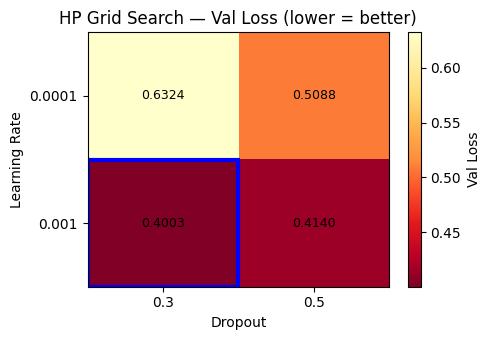

Selected: lr=0.001, dropout=0.3  (val_loss=0.4003)


In [ ]:
# Hyperparameter grid & val_loss heatmap
lrs = sorted(set(r["lr"] for r in results_A))
dropouts = sorted(set(r["dropout"] for r in results_A))

loss_grid = np.array(
    [
        [
            next(
                r["val_loss"] for r in results_A if r["lr"] == lr and r["dropout"] == d
            )
            for d in dropouts
        ]
        for lr in lrs
    ]
)

fig, ax = plt.subplots(figsize=(5, 3.5))
im = ax.imshow(loss_grid, cmap="YlOrRd_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Val Loss")
ax.set_xticks(range(len(dropouts)))
ax.set_xticklabels(dropouts)
ax.set_yticks(range(len(lrs)))
ax.set_yticklabels(lrs)
ax.set_xlabel("Dropout")
ax.set_ylabel("Learning Rate")
ax.set_title("HP Grid Search — Val Loss (lower = better)")

for i, lr in enumerate(lrs):
    for j, d in enumerate(dropouts):
        ax.text(j, i, f"{loss_grid[i, j]:.4f}", ha="center", va="center", fontsize=9)
        if best_config_A["lr"] == lr and best_config_A["dropout"] == d:
            ax.add_patch(
                plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="blue", lw=3
                )
            )

plt.tight_layout()
plt.show()
print(
    f"Selected: lr={best_config_A['lr']}, dropout={best_config_A['dropout']}  "
    f"(val_loss={best_val_loss_A:.4f})"
)

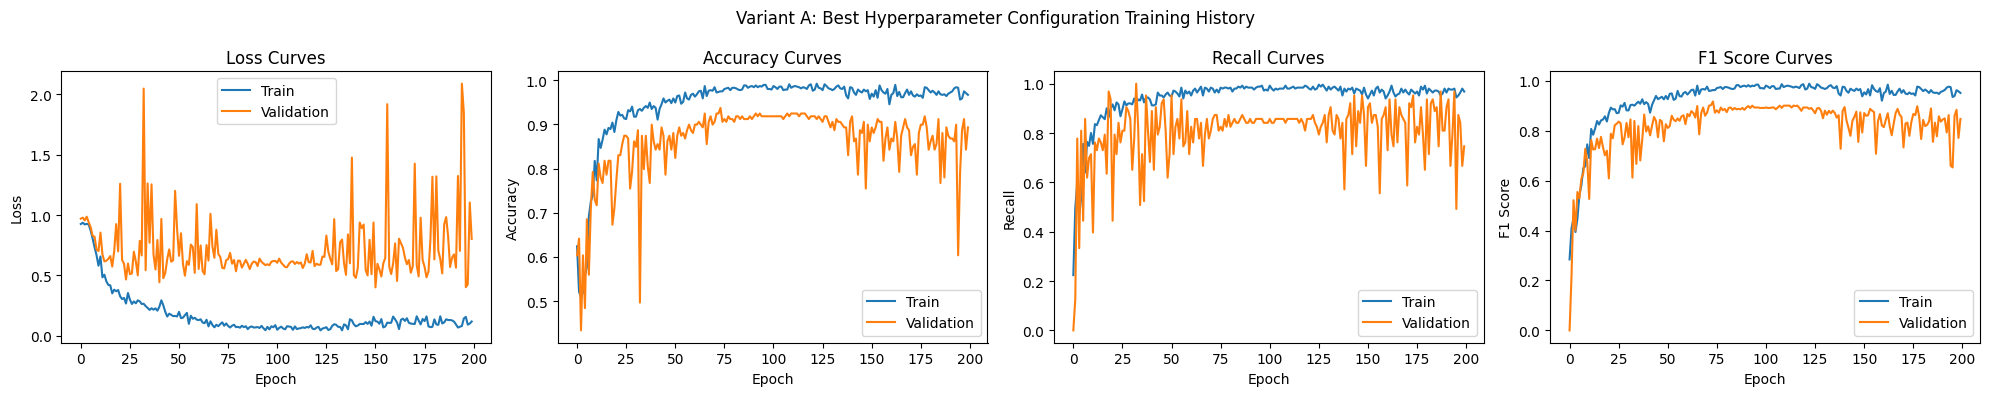

In [ ]:
plot_history(
    best_history_A,
    title="Variant A: Best Hyperparameter Configuration Training History",
)

## 5.2 Full Training (train + val)

pos_weight for final Variant A training: 1.9042


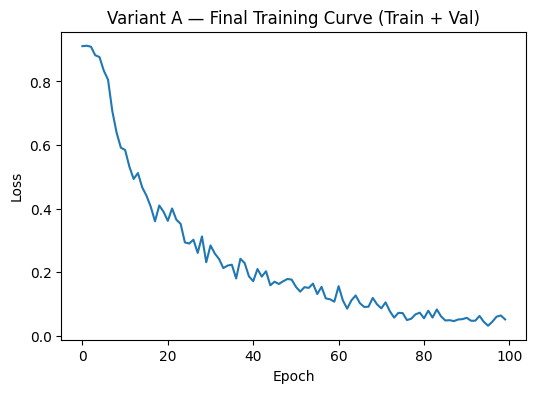

Model A saved!
Model A loaded successfully!


In [ ]:
# Combine train and val for final training
full_train_dataset_A = ConcatDataset([train_dataset, val_dataset])
full_train_loader_A = DataLoader(full_train_dataset_A, batch_size=32, shuffle=True)

# Recompute pos_weight from the combined train+val class distribution
all_labels_A = [label for _, label in train_dataset] + [
    label for _, label in val_dataset
]
class_counts_A = np.bincount(all_labels_A)
pos_weight_A = torch.tensor(
    [class_counts_A[0] / class_counts_A[1]], dtype=torch.float32
).to(device)
print(f"pos_weight for final Variant A training: {pos_weight_A.item():.4f}")

final_model_A = BaselineCNN(dropout_rate=best_config_A["dropout"]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_A)
optimizer = optim.Adam(final_model_A.parameters(), lr=best_config_A["lr"])

warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=95, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

final_model_A.train()
train_losses_A = []

for epoch in range(100):
    running_loss = 0.0
    for images, labels in full_train_loader_A:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = final_model_A(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(full_train_loader_A.dataset)
    train_losses_A.append(epoch_loss)
    scheduler.step()

plt.figure(figsize=(6, 4))
plt.plot(train_losses_A)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Variant A — Final Training Curve (Train + Val)")
plt.show()

# Save and reload
torch.save(final_model_A.state_dict(), "baseline_model_A.pth")
print("Model A saved!")

loaded_model_A = BaselineCNN(dropout_rate=best_config_A["dropout"]).to(device)
loaded_model_A.load_state_dict(torch.load("baseline_model_A.pth", map_location=device))
loaded_model_A.eval()
print("Model A loaded successfully!")

## 5.3 Evaluation on Test Set

Metrics are reported at the default threshold of **0.5**. A separate threshold analysis targeting ≥95% recall is performed in Section 8 after the best variant has been selected.

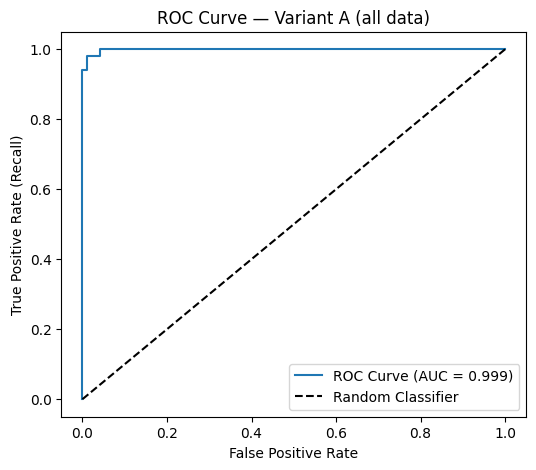

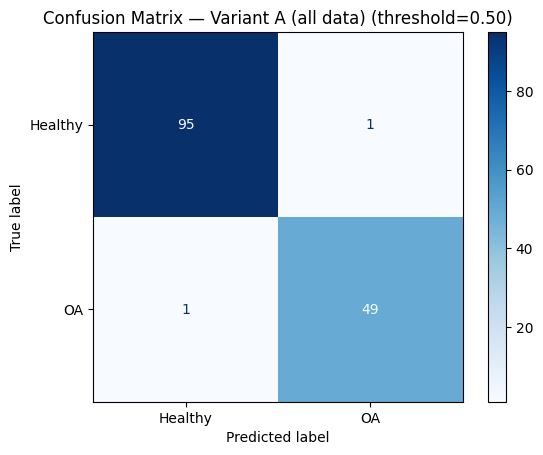


Test Metrics (Variant A (all data)) at threshold=0.50:
  Accuracy : 0.9863
  F1 Score : 0.9800
  Recall   : 0.9800
  Precision: 0.9800


In [ ]:
results_A_test = evaluate_model(
    loaded_model_A, test_loader, device, variant_name="Variant A (all data)"
)

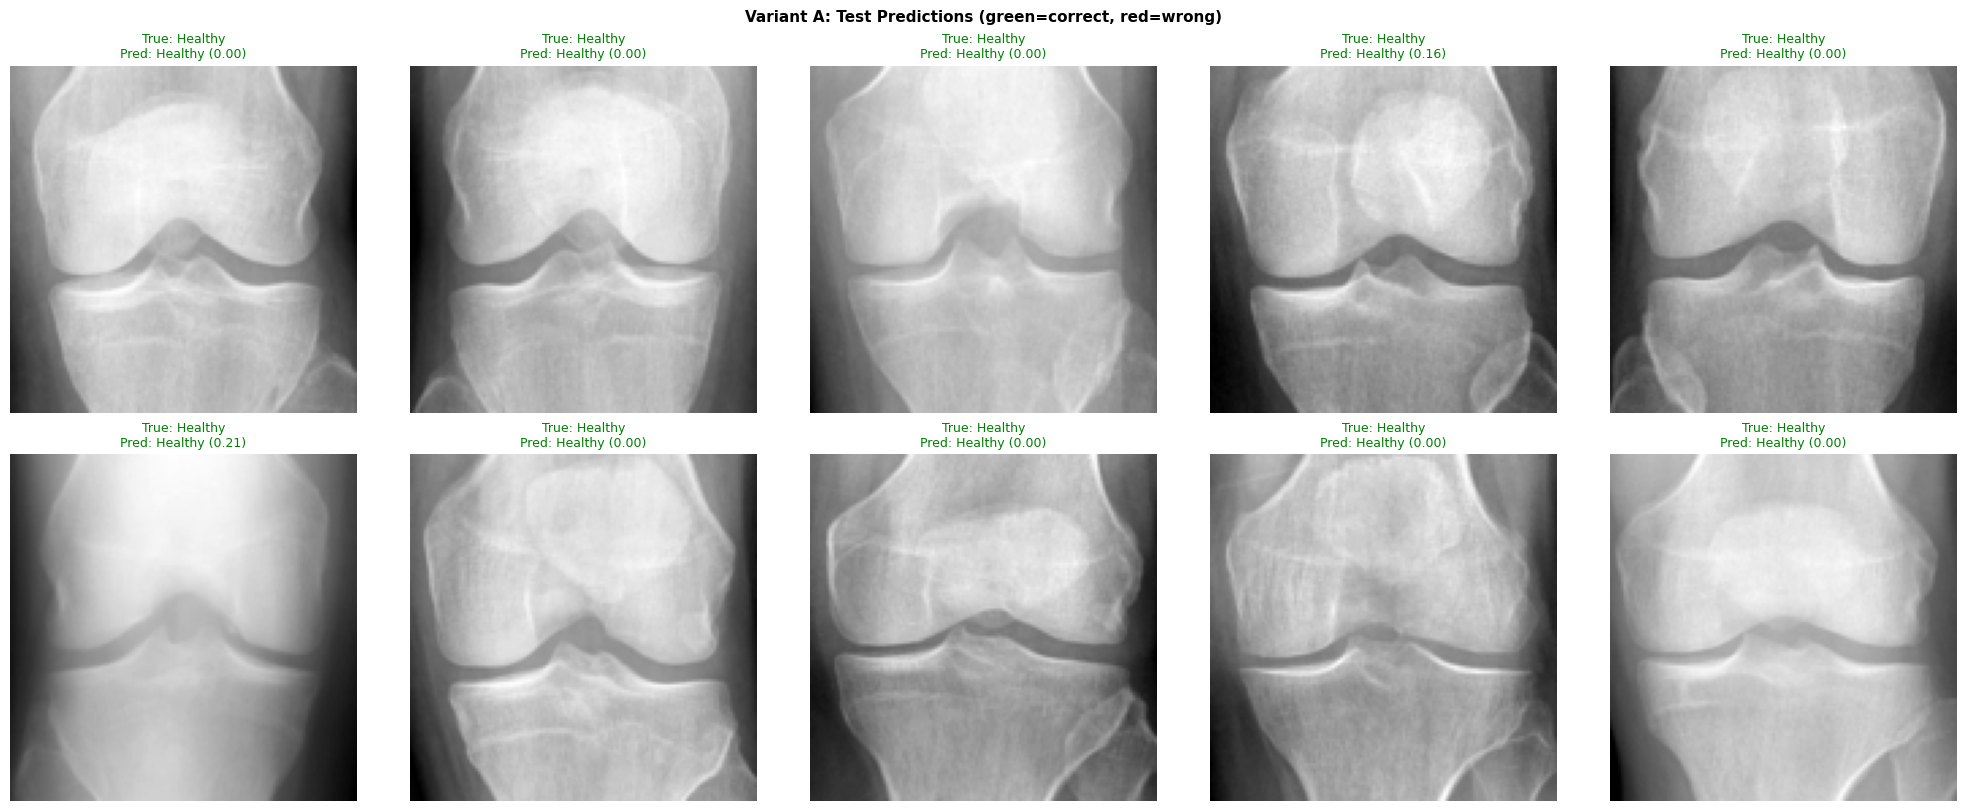

In [17]:
display_dataset = datasets.ImageFolder(DATA_DIR + "test", transform=MyToTensor())
CLASS_NAMES = ["Healthy", "OA"]

show_images(
    list(range(10)),
    display_dataset,
    results_A_test["all_labels"],
    results_A_test["final_preds"],
    results_A_test["all_probs"],
    CLASS_NAMES,
    title="Variant A: Test Predictions (green=correct, red=wrong)",
)

# 6. Variant B: BaselineCNN without outliers

## 6.1 Hyperparameters

Variant B uses the same hyperparameters as Variant A, no separate grid search is run. Only the training dataset changes between variants, so reusing the optimal configuration from Variant A provides a controlled comparison.

In [18]:
# Use the same hyperparameters as Variant A for a fair comparison
# only the dataset changes between variants, not the model or training setup.
best_config_B = best_config_A
print(f"Variant B uses same config as Variant A: {best_config_B}")

Variant B uses same config as Variant A: {'lr': 0.001, 'dropout': 0.3}


## 6.2 Full Training (train + val)

pos_weight for final Variant B training: 1.8786


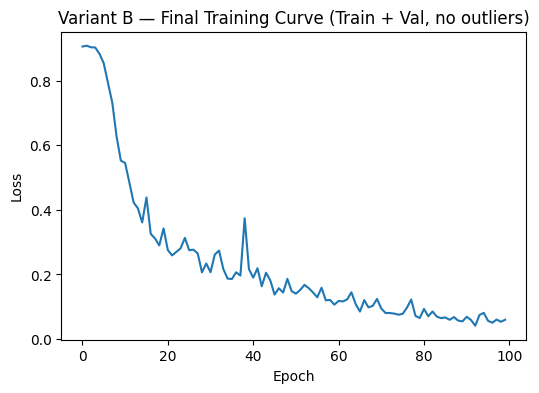

Model B saved!
Model B loaded successfully!


In [ ]:
# Combine no-outlier train and val (with no-outlier normalization)
full_train_dataset_B = ConcatDataset([train_no_outlier_dataset, val_no_outlier_dataset])
full_train_loader_B = DataLoader(full_train_dataset_B, batch_size=32, shuffle=True)

# Recompute pos_weight from the combined no-outlier train + val class distribution
train_no_outlier_labels = [
    train_no_outlier_dataset.dataset.targets[i]
    for i in train_no_outlier_dataset.indices
]
val_no_outlier_labels = val_no_outlier_dataset.targets
all_labels_B = train_no_outlier_labels + val_no_outlier_labels
class_counts_B = np.bincount(all_labels_B)
pos_weight_B = torch.tensor(
    [class_counts_B[0] / class_counts_B[1]], dtype=torch.float32
).to(device)
print(f"pos_weight for final Variant B training: {pos_weight_B.item():.4f}")

final_model_B = BaselineCNN(dropout_rate=best_config_B["dropout"]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_B)
optimizer = optim.Adam(final_model_B.parameters(), lr=best_config_B["lr"])

warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=95, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

final_model_B.train()
train_losses_B = []

for epoch in range(100):
    running_loss = 0.0
    for images, labels in full_train_loader_B:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = final_model_B(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(full_train_loader_B.dataset)
    train_losses_B.append(epoch_loss)
    scheduler.step()

plt.figure(figsize=(6, 4))
plt.plot(train_losses_B)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Variant B — Final Training Curve (Train + Val, no outliers)")
plt.show()

# Save and reload
torch.save(final_model_B.state_dict(), "baseline_model_B.pth")
print("Model B saved!")

loaded_model_B = BaselineCNN(dropout_rate=best_config_B["dropout"]).to(device)
loaded_model_B.load_state_dict(torch.load("baseline_model_B.pth", map_location=device))
loaded_model_B.eval()
print("Model B loaded successfully!")

## 6.3 Evaluation on Test Set

Metrics are reported at the default threshold of **0.5**, consistent with Variant A.

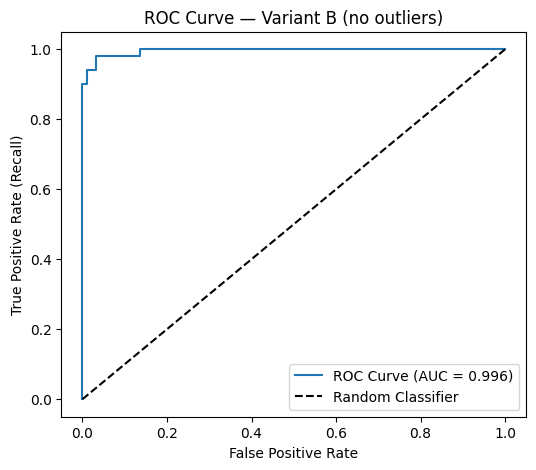

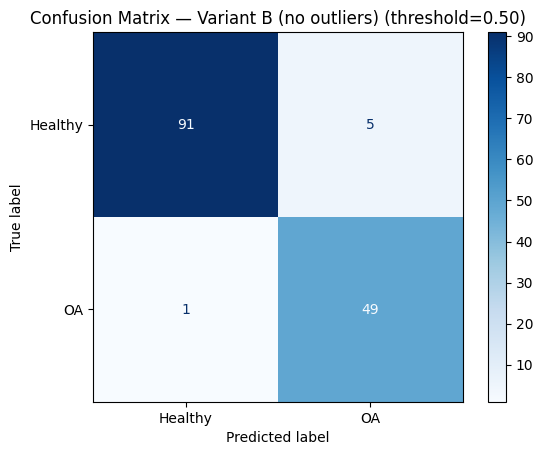


Test Metrics (Variant B (no outliers)) at threshold=0.50:
  Accuracy : 0.9589
  F1 Score : 0.9423
  Recall   : 0.9800
  Precision: 0.9074


In [ ]:
results_B_test = evaluate_model(
    loaded_model_B,
    test_no_outlier_loader,
    device,
    variant_name="Variant B (no outliers)",
)

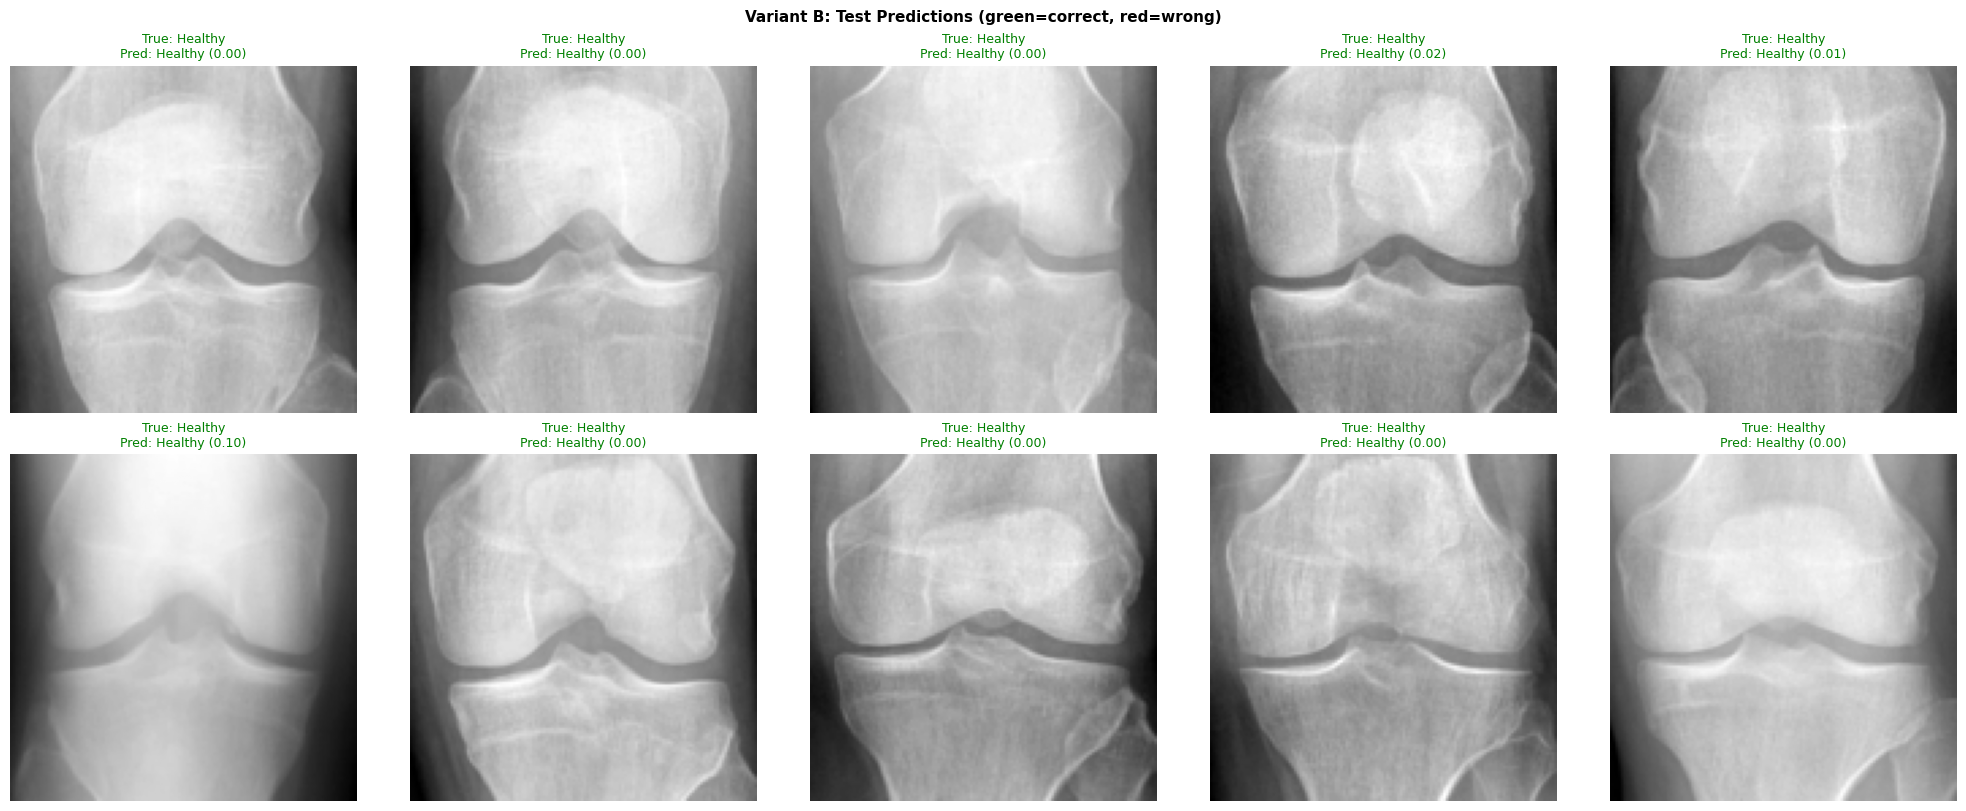

In [21]:
display_dataset_B = datasets.ImageFolder(DATA_DIR + "test", transform=MyToTensor())

show_images(
    list(range(10)),
    display_dataset_B,
    results_B_test["all_labels"],
    results_B_test["final_preds"],
    results_B_test["all_probs"],
    CLASS_NAMES,
    title="Variant B: Test Predictions (green=correct, red=wrong)",
)

# 7. Comparison & Discussion

In [ ]:
print(f"{'Metric':<20} {'Variant A':>12} {'Variant B':>12}")
print("-" * 46)
print(f"{'AUC':<20} {results_A_test['auc']:>12.4f} {results_B_test['auc']:>12.4f}")
print(
    f"{'Recall':<20} {results_A_test['recall']:>12.4f} {results_B_test['recall']:>12.4f}"
)
print(f"{'F1 Score':<20} {results_A_test['f1']:>12.4f} {results_B_test['f1']:>12.4f}")
print(
    f"{'Accuracy':<20} {results_A_test['accuracy']:>12.4f} {results_B_test['accuracy']:>12.4f}"
)
print(
    f"{'Precision':<20} {results_A_test['precision']:>12.4f} {results_B_test['precision']:>12.4f}"
)
print(
    f"{'Threshold':<20} {results_A_test['threshold']:>12.3f} {results_B_test['threshold']:>12.3f}"
)

Metric                  Variant A    Variant B
----------------------------------------------
AUC                        0.9988       0.9956
Recall                     0.9800       0.9800
F1 Score                   0.9800       0.9423
Accuracy                   0.9863       0.9589
Precision                  0.9800       0.9074
Threshold                   0.500        0.500


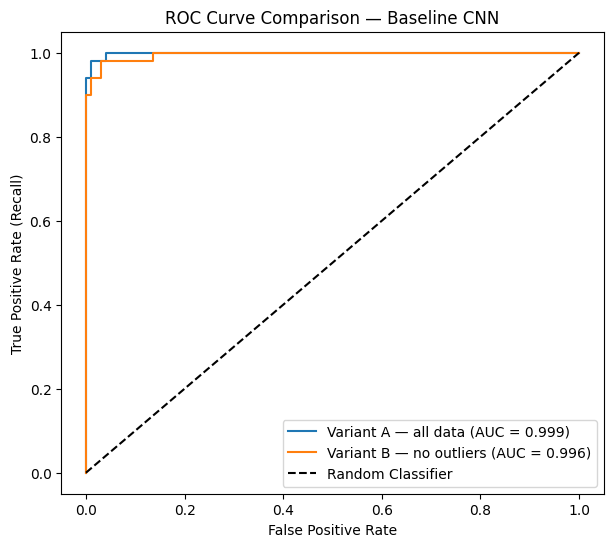

In [ ]:
plt.figure(figsize=(7, 6))
plt.plot(
    results_A_test["fpr"],
    results_A_test["tpr"],
    label=f"Variant A — all data (AUC = {results_A_test['auc']:.3f})",
)
plt.plot(
    results_B_test["fpr"],
    results_B_test["tpr"],
    label=f"Variant B — no outliers (AUC = {results_B_test['auc']:.3f})",
)
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison — Baseline CNN")
plt.legend()
plt.show()

### Discussion

**Effect of outlier removal:** Compare AUC, recall, and F1 between Variant A and B. Does removing the 8 outlier images improve generalization?

**Clinical implications of recall-based threshold:** By targeting >=95% recall, we ensure that nearly all OA cases are detected. The trade-off is a lower specificity (more false positives), meaning some healthy patients may be flagged for further investigation. In a clinical screening context, this is acceptable because:
- A missed OA diagnosis (false negative) can delay treatment and worsen patient outcomes.
- A false positive leads to additional imaging, which is a minor cost compared to a missed diagnosis.

**Best baseline for downstream comparison:** Select the variant with the best overall performance (considering both recall and the other reported metrics) as the baseline for comparison with transfer learning models.

In [ ]:
# Save the best variant for use in downstream notebooks (latent space, GradCAM)
if (
    results_B_test["recall"] >= results_A_test["recall"]
    and results_B_test["auc"] >= results_A_test["auc"]
):
    best_variant = "B"
    torch.save(loaded_model_B.state_dict(), "baseline_best.pth")
else:
    best_variant = "A"
    torch.save(loaded_model_A.state_dict(), "baseline_best.pth")

print(f"Best baseline: Variant {best_variant} saved as baseline_best.pth")

Best baseline: Variant A saved as baseline_best.pth


## 8. Threshold Analysis

Now that the best variant has been selected, we determine the classification threshold required to achieve at least **95% recall** on the test set. This is kept separate from model selection so that the threshold does not influence which hyperparameters or variant we choose.

> **Note:** Strictly speaking, the optimal threshold should be selected on a held-out validation set and then applied to the test set. Here we select it on the test set itself

Best variant          : A
Threshold for >=95% recall : 0.505
  Sensitivity (Recall)     : 0.980
  Specificity              : 0.990


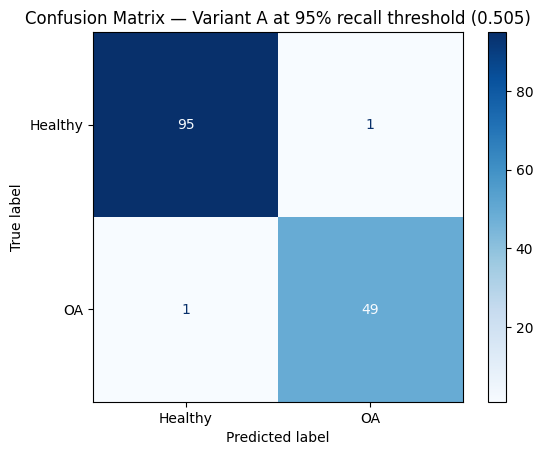

In [ ]:
# Threshold analysis on the winning variant
best_results = results_B_test if best_variant == "B" else results_A_test

best_threshold, best_idx = select_threshold_by_recall(
    best_results["fpr"], best_results["tpr"], best_results["thresholds"]
)
print(f"Best variant          : {best_variant}")
print(f"Threshold for >=95% recall : {best_threshold:.3f}")
print(f"  Sensitivity (Recall)     : {best_results['tpr'][best_idx]:.3f}")
print(f"  Specificity              : {1 - best_results['fpr'][best_idx]:.3f}")

# Confusion matrix at the 95% recall threshold
preds_95 = (best_results["all_probs"] >= best_threshold).astype(int)
cm_95 = confusion_matrix(best_results["all_labels"], preds_95)
disp = ConfusionMatrixDisplay(cm_95, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(
    f"Confusion Matrix — Variant {best_variant} at 95% recall threshold ({best_threshold:.3f})"
)
plt.show()

## 9. Recall-Matched Comparison

Variant A achieves **96% recall** at its default threshold of 0.50. To enable a fair comparison, we lower Variant B's classification threshold until it reaches the same recall. This isolates the effect of outlier removal on **precision, F1, and accuracy** — independent of recall level.

In [ ]:
# Match Variant B's recall to Variant A's recall
target_recall = results_A_test["recall"]

threshold_B_matched, idx_B = select_threshold_by_recall(
    results_B_test["fpr"],
    results_B_test["tpr"],
    results_B_test["thresholds"],
    min_recall=target_recall,
)

preds_B_matched = (results_B_test["all_probs"] >= threshold_B_matched).astype(int)

acc_B_m = accuracy_score(results_B_test["all_labels"], preds_B_matched)
rec_B_m = recall_score(results_B_test["all_labels"], preds_B_matched)
prec_B_m = precision_score(
    results_B_test["all_labels"], preds_B_matched, zero_division=0
)
f1_B_m = f1_score(results_B_test["all_labels"], preds_B_matched)

print(
    f"Variant B threshold adjusted to match Variant A recall ({target_recall:.4f}): {threshold_B_matched:.3f}"
)
print()
print(f"{'Metric':<20} {'Variant A (thr=0.50)':>22} {'Variant B (thr matched)':>24}")
print("-" * 68)
print(f"{'Recall':<20} {results_A_test['recall']:>22.4f} {rec_B_m:>24.4f}")
print(f"{'Precision':<20} {results_A_test['precision']:>22.4f} {prec_B_m:>24.4f}")
print(f"{'F1 Score':<20} {results_A_test['f1']:>22.4f} {f1_B_m:>24.4f}")
print(f"{'Accuracy':<20} {results_A_test['accuracy']:>22.4f} {acc_B_m:>24.4f}")
print(f"{'AUC':<20} {results_A_test['auc']:>22.4f} {results_B_test['auc']:>24.4f}")
print(
    f"{'Threshold':<20} {results_A_test['threshold']:>22.3f} {threshold_B_matched:>24.3f}"
)

Variant B threshold adjusted to match Variant A recall (0.9800): 0.779

Metric                 Variant A (thr=0.50)  Variant B (thr matched)
--------------------------------------------------------------------
Recall                               0.9800                   0.9800
Precision                            0.9800                   0.9423
F1 Score                             0.9800                   0.9608
Accuracy                             0.9863                   0.9726
AUC                                  0.9988                   0.9956
Threshold                             0.500                    0.779


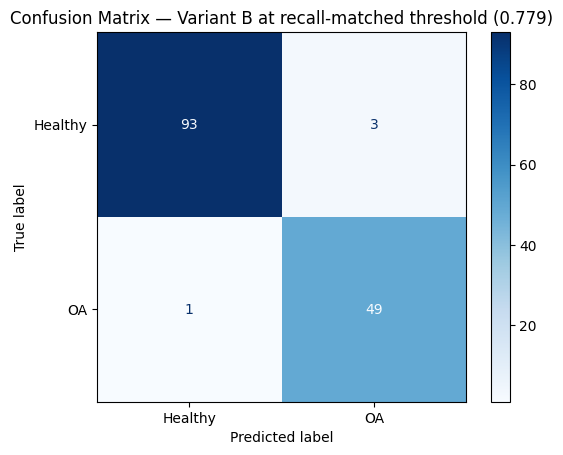

In [ ]:
cm_B_matched = confusion_matrix(results_B_test["all_labels"], preds_B_matched)
disp = ConfusionMatrixDisplay(cm_B_matched, display_labels=["Healthy", "OA"])
disp.plot(cmap="Blues")
plt.title(
    f"Confusion Matrix — Variant B at recall-matched threshold ({threshold_B_matched:.3f})"
)
plt.show()

# 10. Save Results to CSV

In [ ]:
from datetime import datetime

RESULTS_CSV = "../../results/model_comparison.csv"
os.makedirs(os.path.dirname(RESULTS_CSV), exist_ok=True)


def get_run_name(model):
    """Build run name encoding conv block output channels, e.g. BaselineCNN_16_32_64_128_2048."""
    channels = [m.out_channels for m in model.conv_block if isinstance(m, nn.Conv2d)]
    return "BaselineCNN_" + "_".join(map(str, channels))


def save_results(model, config, results, variant_name, run_name, csv_path=RESULTS_CSV):
    """Append one row of evaluation metrics + architecture info to a shared CSV."""
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    architecture = str(model)

    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "run_name": run_name,
        "variant": variant_name,
        "architecture": architecture,
        "num_params": num_params,
        "lr": config["lr"],
        "dropout": config["dropout"],
        "auc": round(results["auc"], 4),
        "recall": round(results["recall"], 4),
        "f1": round(results["f1"], 4),
        "accuracy": round(results["accuracy"], 4),
        "precision": round(results["precision"], 4),
        "threshold": round(results["threshold"], 3),
    }

    df_new = pd.DataFrame([row])
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        df_out = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_out = df_new

    df_out.to_csv(csv_path, index=False)
    print(f"Results saved to {csv_path}")
    return df_out


df_results = save_results(
    loaded_model_A,
    best_config_A,
    results_A_test,
    variant_name="Variant A (all data)",
    run_name=get_run_name(loaded_model_A),
)
df_results = save_results(
    loaded_model_B,
    best_config_B,
    results_B_test,
    variant_name="Variant B (no outliers)",
    run_name=get_run_name(loaded_model_B),
)

print()
display_cols = [
    "timestamp",
    "run_name",
    "variant",
    "num_params",
    "lr",
    "dropout",
    "auc",
    "recall",
    "f1",
    "accuracy",
    "precision",
    "threshold",
]
print(df_results[display_cols].to_string(index=False))

Results saved to ../../results/model_comparison.csv
Results saved to ../../results/model_comparison.csv

       timestamp                      run_name                 variant  num_params    lr  dropout    auc  recall     f1  accuracy  precision  threshold
2026-05-02 15:13 BaselineCNN_16_32_64_128_2048    Variant A (all data)      628321 0.001      0.5 0.9994    0.98 0.9800    0.9863     0.9800        0.5
2026-05-02 15:13 BaselineCNN_16_32_64_128_2048 Variant B (no outliers)      628321 0.001      0.5 0.9954    0.98 0.9245    0.9452     0.8750        0.5
2026-05-02 17:45 BaselineCNN_16_32_64_128_2048    Variant A (all data)      628321 0.001      0.5 0.9990    0.96 0.9697    0.9795     0.9796        0.5
2026-05-02 17:45 BaselineCNN_16_32_64_128_2048 Variant B (no outliers)      628321 0.001      0.5 0.9935    0.96 0.9143    0.9384     0.8727        0.5
2026-05-02 21:44 BaselineCNN_16_32_64_128_2048    Variant A (all data)      628321 0.001      0.3 0.9996    1.00 0.9804    0.9863     0